In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.dates as mdates
import matplotlib.ticker as mticker  # 新增這行

In [19]:
# 讀取資料
df = pd.read_csv(r"C:\python\tmba\模型原始data.csv", low_memory=False)

# 定義數值轉換函數
def convert_to_numeric(x):
    if isinstance(x, str):
        try:
            # 移除逗號後轉換為浮點數
            return float(x.replace(',', ''))
        except ValueError:
            return x
    return x

# 處理所有欄位
for col in df.columns:
    # 檢查是否為 object 類型
    if df[col].dtype == 'object':
        # 嘗試轉換
        df[col] = df[col].apply(convert_to_numeric)
        
# 轉換後重新檢查資料類型
string_cols = df.select_dtypes(include=['object']).columns.tolist()

print("轉換後仍為字串類型的欄位:")
print(string_cols)

# 更新排除欄位清單
exclude_cols = string_cols + ['月報酬', '下期月報酬']
exclude_cols = list(set(exclude_cols))

# 初步篩選數值型因子
initial_factors = [col for col in df.columns if col not in exclude_cols]

# 計算每個因子的遺漏值比例
missing_ratio = df[initial_factors].isnull().mean()
valid_missing = missing_ratio[missing_ratio <= 0.10].index.tolist()

print("\n遺漏值篩選:")
print(f"原始因子數量: {len(initial_factors)}")
print(f"遺漏值>10%的因子數量: {len(initial_factors) - len(valid_missing)}")

# 計算每個因子的零值比例
zero_ratio = (df[valid_missing] == 0).mean()
valid_zeros = zero_ratio[zero_ratio <= 0.20].index.tolist()

print("\n零值篩選:")
print(f"通過遺漏值篩選的因子數量: {len(valid_missing)}")
print(f"零值>20%的因子數量: {len(valid_missing) - len(valid_zeros)}")

# 最終的因子列表
factors = valid_zeros

print("\n最終篩選結果:")
print(f"最終保留的因子數量: {len(factors)}")

# 顯示被排除的因子
print("\n因遺漏值過多(>10%)被排除的因子:")
print([f for f in initial_factors if f not in valid_missing])

print("\n因零值過多(>20%)被排除的因子:")
print([f for f in valid_missing if f not in valid_zeros])

# 檢查最終保留的因子的資料型態
print("\n最終保留因子的資料型態:")
print(df[factors].dtypes)

轉換後仍為字串類型的欄位:
['名稱', '年/月', '財報發布日', '財報年月起日', '財報年月迄日', '市場別', '交易所主產業代碼', '交易所子產業代碼', 'TEJ主產業代碼', 'TEJ子產業代碼', '財報附註TEJ是否完成Y/N']

遺漏值篩選:
原始因子數量: 269
遺漏值>10%的因子數量: 50

零值篩選:
通過遺漏值篩選的因子數量: 219
零值>20%的因子數量: 64

最終篩選結果:
最終保留的因子數量: 155

因遺漏值過多(>10%)被排除的因子:
['  合約資產－非流動', '    使用權資產', '  按攤銷後成本衡量之金融負債－流動', '  租賃負債─流動', '  按攤銷後成本衡量之金融負債－非流動', '  合約負債－非流動', '  租賃負債－非流動', '  預期信用減損（損失）利益－營業費用', '預期信用減損（損失）利益', '除列按攤銷後成本衡量金融資產淨損益', '金融資產重分類淨損益', '期中普通股－現金股利', '期中普通股－股票股利', '期中特別股－現金股利', '期中特別股－股票股利', '期末普通股－現金股利', '期末普通股－股票股利', '期末特別股－現金股利', '期末特別股－股票股利', '普通股每股現金股利（盈餘及公積）', '  普通股每股現金股利－盈餘', '  普通股每股現金股利－公積', '普通股每股股票股利－盈餘', '普通股每股股票股利－公積', '資本公積－現金股利', '資本公積轉增資－股票股利', '預計稅額扣抵比率', '稅額扣抵比率', 'BS透過損益按公允價值衡量之金融資產－流動(IFRS)', 'BS持有至到期日金融資產－非流動', 'BS透過損益按公允價值衡量之金融負債－流動(IFRS)', 'BS應付建造合約款', 'BS以成本衡量之金融負債－非流動', '員工人數', '呆帳費用率', '稅率(B)', '營收變動率', '營業利益變動率', '淨利變動率（單季）', '稅前盈餘變動率', '現金流量允當比', '現金再投資比', '內部保留比率', '股利支付率', '營運槓桿度', '財務槓桿度', '每人營收', '每人營業利益', '每人配備率', '當季季底P/E']

因零值過多(>20%)被排除的因子:
['  透過損

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


def _select_factors_by_pvalue(
    train_df,
    candidate_factors,
    top_k=10,
    p_th=0.05,
    min_obs=60,
    corr_threshold=0.80,
    preselect_multiplier=5,
):
    """
    Use only historical data to select significant factors, then deduplicate highly correlated factors.

    Step 1) rank factors by p-value
    Step 2) greedily keep factors with pairwise |corr| < corr_threshold

    Returns
    -------
    selected : list[str]
        Factor names after dedup.
    factor_signs : dict[str, float]
        Training-window univariate OLS sign(coef) in {-1.0, 1.0} per selected factor
        (0 coef treated as +1) for return-aligned z-scores.
    """
    y = pd.to_numeric(train_df['下期月報酬'], errors='coerce')
    records = []

    for f in candidate_factors:
        x = pd.to_numeric(train_df[f], errors='coerce')
        tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
        if len(tmp) < min_obs:
            continue

        X = sm.add_constant(tmp['x'])
        try:
            model = sm.OLS(tmp['y'], X).fit()
            records.append(
                {
                    'factor': f,
                    'pvalue': float(model.pvalues.iloc[1]),
                    'coef': float(model.params.iloc[1]),
                    'nobs': int(model.nobs),
                }
            )
        except Exception:
            continue

    if not records:
        return [], {}

    rank_df = pd.DataFrame(records).sort_values('pvalue')
    sig_df = rank_df[rank_df['pvalue'] < p_th]
    if sig_df.empty:
        sig_df = rank_df

    # Preselect more candidates, then deduplicate by correlation.
    pre_n = max(top_k, top_k * preselect_multiplier)
    pre_candidates = sig_df['factor'].head(pre_n).tolist()

    X_pre = train_df[pre_candidates].apply(pd.to_numeric, errors='coerce')
    corr = X_pre.corr().abs()

    selected = []
    for f in pre_candidates:
        keep = True
        for s in selected:
            c = corr.loc[f, s] if (f in corr.index and s in corr.columns) else 0.0
            if pd.notna(c) and c >= corr_threshold:
                keep = False
                break
        if keep:
            selected.append(f)
        if len(selected) >= top_k:
            break

    coef_by_factor = rank_df.set_index('factor')['coef'].to_dict()
    factor_signs = {}
    for f in selected:
        c = float(coef_by_factor.get(f, 0.0))
        factor_signs[f] = float(np.sign(c)) if c != 0 else 1.0

    return selected, factor_signs


def _build_positions_for_month(test_df, score_col='score', top_n=5):
    """Create monthly long/short portfolio by score ranking."""
    test_df = test_df.copy()
    test_df[score_col] = pd.to_numeric(test_df[score_col], errors='coerce')
    test_df['下期月報酬'] = pd.to_numeric(test_df['下期月報酬'], errors='coerce')
    test_df = test_df.dropna(subset=[score_col, '下期月報酬'])

    if test_df.empty:
        return pd.DataFrame(columns=['代號', '年/月', '持仓', 'score', '下期月報酬'])

    long_df = test_df.nlargest(top_n, score_col).copy()
    long_df['持仓'] = 'LONG'

    short_df = test_df.nsmallest(top_n, score_col).copy()
    short_df['持仓'] = 'SHORT'

    cols = ['代號', '年/月', '持仓', score_col, '下期月報酬']
    return pd.concat([long_df[cols], short_df[cols]], ignore_index=True)


def _fixed_capital_pnl(
    positions_df,
    initial_capital=1_000_000,
    n_stock=10,
    fee_rate=0.002,
    tax_rate=0.0,
    short_borrow_rate_monthly=0.0,
    short_stop_loss_monthly_ret=0.20,
):
    """
    No compounding + carry positions:
    - Same symbol/same side between two months => hold (no trade)
    - Only new/remove/flip positions incur trading cost
    """
    base_cols = [
        '持有期', '多頭損益', '空頭損益', '當月總損益', '交易成本',
        '借券成本', '淨損益', '累積損益', '總價值', '月報酬率_固定本金', '換手率'
    ]
    if positions_df.empty:
        return pd.DataFrame(columns=base_cols)

    rows = []
    cum_pnl = 0.0
    invest_per_stock = initial_capital / n_stock
    prev_map = {}

    for month in sorted(positions_df['年/月'].unique()):
        m = positions_df[positions_df['年/月'] == month].copy()
        # Current target map: {symbol: side}
        curr_map = dict(zip(m['代號'].astype(str), m['持仓']))

        # Gross strategy PnL from current month holdings
        long_pnl = (m[m['持仓'] == 'LONG']['下期月報酬'] * invest_per_stock).sum()

        short_m = m[m['持仓'] == 'SHORT'].copy()
        short_stop_hits = set()
        if not short_m.empty and short_stop_loss_monthly_ret is not None:
            stop_hits_mask = short_m['下期月報酬'] > float(short_stop_loss_monthly_ret)
            short_stop_hits = set(short_m.loc[stop_hits_mask, '代號'].astype(str))
            short_m.loc[stop_hits_mask, '下期月報酬'] = float(short_stop_loss_monthly_ret)
        short_pnl = (-short_m['下期月報酬'] * invest_per_stock).sum()

        gross_pnl = long_pnl + short_pnl

        # Trade-count logic for carry/hold
        trade_units = 0
        universe = set(prev_map.keys()) | set(curr_map.keys())
        for sym in universe:
            prev_side = prev_map.get(sym)
            curr_side = curr_map.get(sym)
            if prev_side is None and curr_side is not None:
                trade_units += 1  # open
            elif prev_side is not None and curr_side is None:
                trade_units += 1  # close
            elif prev_side != curr_side:
                trade_units += 2  # flip: close + open

        # Forced cover trades from short stop-loss hits (extra close trade this month)
        if short_stop_hits:
            trade_units += len(short_stop_hits)
            for sym in short_stop_hits:
                if curr_map.get(sym) == 'SHORT':
                    del curr_map[sym]

        turnover = trade_units / n_stock if n_stock > 0 else 0.0

        # Costs
        traded_notional = trade_units * invest_per_stock
        trading_cost = traded_notional * (fee_rate + tax_rate)
        short_notional = (m['持仓'] == 'SHORT').sum() * invest_per_stock
        borrow_cost = short_notional * short_borrow_rate_monthly

        net_pnl = gross_pnl - trading_cost - borrow_cost
        cum_pnl += net_pnl

        rows.append(
            {
                '持有期': month,
                '多頭損益': float(long_pnl),
                '空頭損益': float(short_pnl),
                '當月總損益': float(gross_pnl),
                '交易成本': float(trading_cost),
                '借券成本': float(borrow_cost),
                '淨損益': float(net_pnl),
                '累積損益': float(cum_pnl),
                '總價值': float(initial_capital + cum_pnl),
                '月報酬率_固定本金': float(net_pnl / initial_capital),
                '換手率': float(turnover),
            }
        )

        prev_map = curr_map

    out = pd.DataFrame(rows)
    out['持有期'] = pd.to_datetime(out['持有期'], format='%Y/%m')
    return out


def walkforward_significant_equal_weight(
    data,
    candidate_factors,
    top_k_factors=10,
    top_n_stocks=5,
    min_train_months=36,
    initial_capital=1_000_000,
    test_months=None,
    short_stop_loss_monthly_ret=0.20,
):
    """
    Walk-forward baseline:
    - month t: select significant factors from months < t
    - month t: score = mean_k sign(β_k) * z_k (train univariate OLS vs 下期月報酬)
    - evaluate using t+1 return (already aligned in 下期月報酬)

    Returns (positions, perf, selection_df) where selection_df has 持有期 and
    selected_factors (comma-separated factor names for that formation month).
    """
    df_wf = data.copy()
    df_wf['年/月'] = df_wf['年/月'].astype(str)
    months = sorted(df_wf['年/月'].dropna().unique())

    all_positions = []
    selection_log = []

    start_i = min_train_months
    if test_months is not None:
        start_i = max(min_train_months, len(months) - int(test_months))

    for i in range(start_i, len(months)):
        t = months[i]
        train = df_wf[df_wf['年/月'] < t].copy()
        test = df_wf[df_wf['年/月'] == t].copy()

        selected, factor_signs = _select_factors_by_pvalue(
            train,
            candidate_factors=candidate_factors,
            top_k=top_k_factors,
            p_th=0.05,
            min_obs=60,
        )
        if not selected or test.empty:
            continue

        train_X = train[selected].apply(pd.to_numeric, errors='coerce')
        test_X = test[selected].apply(pd.to_numeric, errors='coerce')

        fill_values = train_X.mean()
        train_X = train_X.fillna(fill_values)
        test_X = test_X.fillna(fill_values)

        scaler = StandardScaler()
        scaler.fit(train_X)
        test_scaled = pd.DataFrame(
            scaler.transform(test_X),
            columns=selected,
            index=test.index,
        )

        selection_log.append(
            {
                '持有期': t,
                'selected_factors': ', '.join(selected),
            }
        )

        test = test.copy()
        sign_vec = pd.Series({f: factor_signs.get(f, 1.0) for f in selected})
        aligned = test_scaled.mul(sign_vec, axis=1)
        test['score'] = aligned.mean(axis=1)

        pos = _build_positions_for_month(test, score_col='score', top_n=top_n_stocks)
        all_positions.append(pos)

    positions = pd.concat(all_positions, ignore_index=True) if all_positions else pd.DataFrame()
    perf = _fixed_capital_pnl(
        positions,
        initial_capital=initial_capital,
        n_stock=top_n_stocks * 2,
        short_stop_loss_monthly_ret=short_stop_loss_monthly_ret,
    )
    selection_df = pd.DataFrame(selection_log)
    return positions, perf, selection_df


def walkforward_ml_random_forest(
    data,
    feature_factors,
    top_n_stocks=5,
    min_train_months=36,
    initial_capital=1_000_000,
    n_estimators=100,
    random_state=42,
    top_k_factors=20,
    min_train_rows=200,
    verbose=True,
    test_months=None,
    short_stop_loss_monthly_ret=0.20,
):
    """
    Walk-forward ML (ML for scoring only):
    - month t: use historical data (< t) to select factors by p-value + dedup
    - month t: train ONE RandomForest model on selected factors
    - month t: predict next-month return and form long/short portfolio
    """
    df_wf = data.copy()
    df_wf['年/月'] = df_wf['年/月'].astype(str)
    months = sorted(df_wf['年/月'].dropna().unique())

    all_positions = []
    selection_log = []

    start_i = min_train_months
    if test_months is not None:
        start_i = max(min_train_months, len(months) - int(test_months))

    for i in range(start_i, len(months)):
        t = months[i]
        if verbose:
            done = i - start_i + 1
            total = len(months) - start_i
            print(f"[ML walk-forward] {t} ({done}/{total})", flush=True)
        train = df_wf[df_wf['年/月'] < t].copy()
        test = df_wf[df_wf['年/月'] == t].copy()
        if train.empty or test.empty:
            continue

        selected, _ = _select_factors_by_pvalue(
            train,
            candidate_factors=feature_factors,
            top_k=top_k_factors,
            p_th=0.05,
            min_obs=60,
        )
        if not selected:
            continue

        X_train = train[selected].apply(pd.to_numeric, errors='coerce')
        y_train = pd.to_numeric(train['下期月報酬'], errors='coerce')
        X_test = test[selected].apply(pd.to_numeric, errors='coerce')

        valid_idx = y_train.notna()
        X_train = X_train.loc[valid_idx]
        y_train = y_train.loc[valid_idx]
        if len(X_train) < min_train_rows:
            continue

        fill_values = X_train.mean()
        X_train = X_train.fillna(fill_values)
        X_test = X_test.fillna(fill_values)

        selection_log.append(
            {
                '持有期': t,
                'selected_factors': ', '.join(selected),
            }
        )

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=12,
            min_samples_leaf=50,
            random_state=random_state,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

        test = test.copy()
        test['pred_ret'] = model.predict(X_test)

        pos = _build_positions_for_month(test, score_col='pred_ret', top_n=top_n_stocks)
        all_positions.append(pos)

    positions = pd.concat(all_positions, ignore_index=True) if all_positions else pd.DataFrame()
    perf = _fixed_capital_pnl(
        positions,
        initial_capital=initial_capital,
        n_stock=top_n_stocks * 2,
        short_stop_loss_monthly_ret=short_stop_loss_monthly_ret,
    )
    selection_df = pd.DataFrame(selection_log)
    return positions, perf, selection_df


def _walkforward_sklearn_reg(
    data,
    feature_factors,
    build_model,
    top_n_stocks=5,
    min_train_months=36,
    initial_capital=1_000_000,
    top_k_factors=20,
    min_train_rows=200,
    verbose=True,
    log_prefix='[sklearn wf]',
    test_months=None,
    short_stop_loss_monthly_ret=0.20,
):
    """Shared walk-forward loop: p-value factor screen then sklearn regressor fit/predict."""
    df_wf = data.copy()
    df_wf['年/月'] = df_wf['年/月'].astype(str)
    months = sorted(df_wf['年/月'].dropna().unique())
    all_positions = []
    selection_log = []
    start_i = min_train_months
    if test_months is not None:
        start_i = max(min_train_months, len(months) - int(test_months))
    for i in range(start_i, len(months)):
        t = months[i]
        if verbose:
            done = i - start_i + 1
            total = len(months) - start_i
            print(f"{log_prefix} {t} ({done}/{total})", flush=True)
        train = df_wf[df_wf['年/月'] < t].copy()
        test = df_wf[df_wf['年/月'] == t].copy()
        if train.empty or test.empty:
            continue
        selected, _ = _select_factors_by_pvalue(
            train,
            candidate_factors=feature_factors,
            top_k=top_k_factors,
            p_th=0.05,
            min_obs=60,
        )
        if not selected:
            continue
        X_train = train[selected].apply(pd.to_numeric, errors='coerce')
        y_train = pd.to_numeric(train['下期月報酬'], errors='coerce')
        X_test = test[selected].apply(pd.to_numeric, errors='coerce')
        valid_idx = y_train.notna()
        X_train = X_train.loc[valid_idx]
        y_train = y_train.loc[valid_idx]
        if len(X_train) < min_train_rows:
            continue
        fill_values = X_train.mean()
        X_train = X_train.fillna(fill_values)
        X_test = X_test.fillna(fill_values)
        selection_log.append(
            {'持有期': t, 'selected_factors': ', '.join(selected)}
        )
        model = build_model()
        try:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
        except Exception:
            continue
        test = test.copy()
        test['pred_ret'] = pred
        pos = _build_positions_for_month(test, score_col='pred_ret', top_n=top_n_stocks)
        all_positions.append(pos)
    positions = pd.concat(all_positions, ignore_index=True) if all_positions else pd.DataFrame()
    perf = _fixed_capital_pnl(
        positions,
        initial_capital=initial_capital,
        n_stock=top_n_stocks * 2,
        short_stop_loss_monthly_ret=short_stop_loss_monthly_ret,
    )
    selection_df = pd.DataFrame(selection_log)
    return positions, perf, selection_df


def walkforward_lasso_regression(
    data,
    feature_factors,
    top_n_stocks=5,
    min_train_months=36,
    initial_capital=1_000_000,
    lasso_alpha=1e-4,
    random_state=42,
    top_k_factors=20,
    min_train_rows=200,
    verbose=True,
    test_months=None,
    short_stop_loss_monthly_ret=0.20,
):
    """Lasso on standardized features (Pipeline); same screen as RF."""
    def build_model():
        return Pipeline([
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=lasso_alpha, max_iter=100000, random_state=random_state)),
        ])
    return _walkforward_sklearn_reg(
        data,
        feature_factors,
        build_model,
        top_n_stocks=top_n_stocks,
        min_train_months=min_train_months,
        initial_capital=initial_capital,
        top_k_factors=top_k_factors,
        min_train_rows=min_train_rows,
        verbose=verbose,
        log_prefix='[Lasso walk-forward]',
        test_months=test_months,
        short_stop_loss_monthly_ret=short_stop_loss_monthly_ret,
    )


def walkforward_gradient_boosting(
    data,
    feature_factors,
    top_n_stocks=5,
    min_train_months=36,
    initial_capital=1_000_000,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    min_samples_leaf=50,
    random_state=42,
    top_k_factors=20,
    min_train_rows=200,
    verbose=True,
    test_months=None,
    short_stop_loss_monthly_ret=0.20,
):
    """sklearn GradientBoostingRegressor; same factor screen as RF."""
    def build_model():
        return GradientBoostingRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            min_samples_leaf=min_samples_leaf,
            random_state=random_state,
        )
    return _walkforward_sklearn_reg(
        data,
        feature_factors,
        build_model,
        top_n_stocks=top_n_stocks,
        min_train_months=min_train_months,
        initial_capital=initial_capital,
        top_k_factors=top_k_factors,
        min_train_rows=min_train_rows,
        verbose=verbose,
        log_prefix='[GBM walk-forward]',
        test_months=test_months,
        short_stop_loss_monthly_ret=short_stop_loss_monthly_ret,
    )

In [21]:
# ===== Walk-forward backtest (no look-ahead, fixed capital) =====
# You can tune these parameters.
TOP_K_FACTORS = 10
TOP_N_STOCKS = 5
MIN_TRAIN_MONTHS = 24  # faster; use 36 for final report if needed
# 全樣本回測：walkforward_* 不傳 test_months（None）。若要只跑最近 N 個月再傳 test_months=N。
INITIAL_CAPITAL = 1_000_000
SHORT_STOP_LOSS_MONTHLY_RET = 0.20  # short leg monthly stop; None to disable
RF_N_ESTIMATORS = 80  # raise to 200–300 for final run
LASSO_ALPHA = 1e-4  # 調大 → 更稀疏；可試 1e-3、1e-2
GBM_N_ESTIMATORS = 100
GBM_MAX_DEPTH = 3
GBM_LEARNING_RATE = 0.05

# Baseline: significant-factor equal-weight scoring
wf_positions_eq, wf_perf_eq, wf_eq_selected_factors = walkforward_significant_equal_weight(
    data=df,
    candidate_factors=factors,
    top_k_factors=TOP_K_FACTORS,
    top_n_stocks=TOP_N_STOCKS,
    min_train_months=MIN_TRAIN_MONTHS,
    initial_capital=INITIAL_CAPITAL,
    short_stop_loss_monthly_ret=SHORT_STOP_LOSS_MONTHLY_RET,
)

# ML: RandomForest scoring (factors selected by p-value + dedup)
wf_positions_ml, wf_perf_ml, wf_ml_selected_factors = walkforward_ml_random_forest(
    data=df,
    feature_factors=factors,
    top_n_stocks=TOP_N_STOCKS,
    min_train_months=MIN_TRAIN_MONTHS,
    initial_capital=INITIAL_CAPITAL,
    n_estimators=RF_N_ESTIMATORS,
    random_state=42,
    top_k_factors=TOP_K_FACTORS,
    short_stop_loss_monthly_ret=SHORT_STOP_LOSS_MONTHLY_RET,
)
print('RandomForest walk-forward 完成。接著跑 Lasso（verbose=False，無逐月 log，約同樣月數）…', flush=True)

wf_positions_lasso, wf_perf_lasso, wf_lasso_selected_factors = walkforward_lasso_regression(
    data=df,
    feature_factors=factors,
    top_n_stocks=TOP_N_STOCKS,
    min_train_months=MIN_TRAIN_MONTHS,
    initial_capital=INITIAL_CAPITAL,
    lasso_alpha=LASSO_ALPHA,
    random_state=42,
    top_k_factors=TOP_K_FACTORS,
    verbose=False,
    short_stop_loss_monthly_ret=SHORT_STOP_LOSS_MONTHLY_RET,
)
print('Lasso walk-forward 完成。接著跑 GBM（verbose=False）…', flush=True)

wf_positions_gbm, wf_perf_gbm, wf_gbm_selected_factors = walkforward_gradient_boosting(
    data=df,
    feature_factors=factors,
    top_n_stocks=TOP_N_STOCKS,
    min_train_months=MIN_TRAIN_MONTHS,
    initial_capital=INITIAL_CAPITAL,
    n_estimators=GBM_N_ESTIMATORS,
    max_depth=GBM_MAX_DEPTH,
    learning_rate=GBM_LEARNING_RATE,
    random_state=42,
    top_k_factors=TOP_K_FACTORS,
    verbose=False,
    short_stop_loss_monthly_ret=SHORT_STOP_LOSS_MONTHLY_RET,
)
print('GBM walk-forward 完成。以下匯總各策略績效。', flush=True)

print('=== Walk-forward Equal-Weight (Significant Factors) ===')
print(wf_perf_eq.tail())
print('\nFinal value:', wf_perf_eq['總價值'].iloc[-1] if not wf_perf_eq.empty else 'N/A')

print('\n=== Walk-forward ML (RandomForest) ===')
print(wf_perf_ml.tail())
print('\nFinal value:', wf_perf_ml['總價值'].iloc[-1] if not wf_perf_ml.empty else 'N/A')

print('\n=== Walk-forward Lasso ===')
print(wf_perf_lasso.tail())
print('\nFinal value:', wf_perf_lasso['總價值'].iloc[-1] if not wf_perf_lasso.empty else 'N/A')

print('\n=== Walk-forward GBM ===')
print(wf_perf_gbm.tail())
print('\nFinal value:', wf_perf_gbm['總價值'].iloc[-1] if not wf_perf_gbm.empty else 'N/A')

# Save outputs for later analysis
wf_positions_eq.to_csv(r"C:\python\tmba\wf_positions_equal_weight.csv", index=False)
wf_perf_eq.to_csv(r"C:\python\tmba\wf_backtest_equal_weight.csv", index=False)
wf_positions_ml.to_csv(r"C:\python\tmba\wf_positions_ml_rf.csv", index=False)
wf_perf_ml.to_csv(r"C:\python\tmba\wf_backtest_ml_rf.csv", index=False)
wf_ml_selected_factors.to_csv(r"C:\python\tmba\wf_ml_selected_factors.csv", index=False)
wf_eq_selected_factors.to_csv(r"C:\python\tmba\wf_eq_selected_factors.csv", index=False)
wf_positions_lasso.to_csv(r"C:\python\tmba\wf_positions_lasso.csv", index=False)
wf_perf_lasso.to_csv(r"C:\python\tmba\wf_backtest_lasso.csv", index=False)
wf_lasso_selected_factors.to_csv(r"C:\python\tmba\wf_lasso_selected_factors.csv", index=False)
wf_positions_gbm.to_csv(r"C:\python\tmba\wf_positions_gbm.csv", index=False)
wf_perf_gbm.to_csv(r"C:\python\tmba\wf_backtest_gbm.csv", index=False)
wf_gbm_selected_factors.to_csv(r"C:\python\tmba\wf_gbm_selected_factors.csv", index=False)

# 每月策略報酬率（EW vs ML 對照；不畫圖也會存，幾乎不增加耗時）
monthly_rets_ew_ml = pd.DataFrame()
try:
    parts = []
    if not wf_perf_eq.empty:
        e = wf_perf_eq[['持有期', '月報酬率_固定本金']].copy()
        e['持有期'] = pd.to_datetime(e['持有期'])
        parts.append(e.rename(columns={'月報酬率_固定本金': 'EW_月報酬率'}))
    if not wf_perf_ml.empty:
        m = wf_perf_ml[['持有期', '月報酬率_固定本金']].copy()
        m['持有期'] = pd.to_datetime(m['持有期'])
        parts.append(m.rename(columns={'月報酬率_固定本金': 'ML_月報酬率'}))
    if not wf_perf_lasso.empty:
        la = wf_perf_lasso[['持有期', '月報酬率_固定本金']].copy()
        la['持有期'] = pd.to_datetime(la['持有期'])
        parts.append(la.rename(columns={'月報酬率_固定本金': 'Lasso_月報酬率'}))
    if not wf_perf_gbm.empty:
        g = wf_perf_gbm[['持有期', '月報酬率_固定本金']].copy()
        g['持有期'] = pd.to_datetime(g['持有期'])
        parts.append(g.rename(columns={'月報酬率_固定本金': 'GBM_月報酬率'}))
    if parts:
        monthly_rets_ew_ml = parts[0]
        for p in parts[1:]:
            monthly_rets_ew_ml = monthly_rets_ew_ml.merge(p, on='持有期', how='outer')
        monthly_rets_ew_ml = monthly_rets_ew_ml.sort_values('持有期')
        monthly_rets_ew_ml.to_csv(r"C:\python\tmba\wf_monthly_returns_all_strategies.csv", index=False)
        print('Saved: C:\\python\\tmba\\wf_monthly_returns_all_strategies.csv')
except Exception as _e:
    print('monthly return export skipped:', _e)

# Excel summary (needs: pip install openpyxl)
try:
    xlsx_path = r"C:\python\tmba\walkforward_results.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        if not wf_perf_eq.empty:
            wf_perf_eq.to_excel(writer, sheet_name="EW_perf", index=False)
        if not wf_perf_ml.empty:
            wf_perf_ml.to_excel(writer, sheet_name="ML_perf", index=False)
        if not wf_perf_lasso.empty:
            wf_perf_lasso.to_excel(writer, sheet_name="Lasso_perf", index=False)
        if not wf_perf_gbm.empty:
            wf_perf_gbm.to_excel(writer, sheet_name="GBM_perf", index=False)
        if not monthly_rets_ew_ml.empty:
            monthly_rets_ew_ml.to_excel(writer, sheet_name="monthly_rets", index=False)
        if not wf_positions_eq.empty:
            wf_positions_eq.to_excel(writer, sheet_name="EW_positions", index=False)
        if not wf_positions_ml.empty:
            wf_positions_ml.to_excel(writer, sheet_name="ML_positions", index=False)
        if not wf_positions_lasso.empty:
            wf_positions_lasso.to_excel(writer, sheet_name="Lasso_positions", index=False)
        if not wf_positions_gbm.empty:
            wf_positions_gbm.to_excel(writer, sheet_name="GBM_positions", index=False)
        if not wf_ml_selected_factors.empty:
            wf_ml_selected_factors.to_excel(writer, sheet_name="ML_factors", index=False)
        if not wf_eq_selected_factors.empty:
            wf_eq_selected_factors.to_excel(writer, sheet_name="EW_factors", index=False)
        if not wf_lasso_selected_factors.empty:
            wf_lasso_selected_factors.to_excel(writer, sheet_name="Lasso_factors", index=False)
        if not wf_gbm_selected_factors.empty:
            wf_gbm_selected_factors.to_excel(writer, sheet_name="GBM_factors", index=False)
    print(f"Saved Excel: {xlsx_path}")
except Exception as e:
    print(f"Excel export skipped ({e}). Install: pip install openpyxl")

print('\nEW / ML 各月選入因子（欄位 selected_factors 為逗號分隔名稱）')
print('EW head:')
print(wf_eq_selected_factors.head())
print('\nML head:')
print(wf_ml_selected_factors.head())


def _build_monthly_trade_factor_table(positions_df, factors_df, prefix):
    if positions_df.empty:
        out = factors_df.copy() if not factors_df.empty else pd.DataFrame(columns=['持有期'])
        out[f'{prefix}_LONG_代號'] = ''
        out[f'{prefix}_SHORT_代號'] = ''
        return out

    p = positions_df.copy()
    p['年/月'] = p['年/月'].astype(str)

    long_tbl = (
        p[p['持仓'] == 'LONG']
        .groupby('年/月')['代號']
        .apply(lambda s: ', '.join(sorted(set(s.astype(str)))))
        .reset_index(name=f'{prefix}_LONG_代號')
    )
    short_tbl = (
        p[p['持仓'] == 'SHORT']
        .groupby('年/月')['代號']
        .apply(lambda s: ', '.join(sorted(set(s.astype(str)))))
        .reset_index(name=f'{prefix}_SHORT_代號')
    )

    out = long_tbl.merge(short_tbl, on='年/月', how='outer')
    if not factors_df.empty:
        out = out.merge(
            factors_df.rename(columns={'持有期': '年/月', 'selected_factors': f'{prefix}_selected_factors'}),
            on='年/月',
            how='outer',
        )
    out = out.rename(columns={'年/月': '持有期'}).sort_values('持有期').reset_index(drop=True)
    return out


monthly_trade_factors_ew = _build_monthly_trade_factor_table(wf_positions_eq, wf_eq_selected_factors, 'EW')
monthly_trade_factors_ml = _build_monthly_trade_factor_table(wf_positions_ml, wf_ml_selected_factors, 'ML')

trade_factor_xlsx = r"C:\python\tmba\wf_trade_and_factors.xlsx"
try:
    with pd.ExcelWriter(trade_factor_xlsx, engine="openpyxl") as writer:
        monthly_trade_factors_ew.to_excel(writer, sheet_name="EW_trade_factors", index=False)
        monthly_trade_factors_ml.to_excel(writer, sheet_name="ML_trade_factors", index=False)
    print(f"Saved trade/factor Excel: {trade_factor_xlsx}")
except Exception as e:
    print(f"Trade/factor Excel export skipped ({e}). Install: pip install openpyxl")

# Optional quick comparison
comparison = pd.DataFrame({
    '持有期': pd.to_datetime(wf_perf_eq['持有期']) if not wf_perf_eq.empty else pd.Series(dtype='datetime64[ns]'),
    'EW_總價值': wf_perf_eq['總價值'] if not wf_perf_eq.empty else pd.Series(dtype='float64'),
}).merge(
    pd.DataFrame({
        '持有期': pd.to_datetime(wf_perf_ml['持有期']) if not wf_perf_ml.empty else pd.Series(dtype='datetime64[ns]'),
        'ML_總價值': wf_perf_ml['總價值'] if not wf_perf_ml.empty else pd.Series(dtype='float64'),
    }),
    on='持有期',
    how='outer'
).merge(
    pd.DataFrame({
        '持有期': pd.to_datetime(wf_perf_lasso['持有期']) if not wf_perf_lasso.empty else pd.Series(dtype='datetime64[ns]'),
        'Lasso_總價值': wf_perf_lasso['總價值'] if not wf_perf_lasso.empty else pd.Series(dtype='float64'),
    }),
    on='持有期',
    how='outer'
).merge(
    pd.DataFrame({
        '持有期': pd.to_datetime(wf_perf_gbm['持有期']) if not wf_perf_gbm.empty else pd.Series(dtype='datetime64[ns]'),
        'GBM_總價值': wf_perf_gbm['總價值'] if not wf_perf_gbm.empty else pd.Series(dtype='float64'),
    }),
    on='持有期',
    how='outer'
).sort_values('持有期')

comparison.head()

[ML walk-forward] 2017/01 (1/98)
[ML walk-forward] 2017/02 (2/98)
[ML walk-forward] 2017/03 (3/98)
[ML walk-forward] 2017/04 (4/98)
[ML walk-forward] 2017/05 (5/98)
[ML walk-forward] 2017/06 (6/98)
[ML walk-forward] 2017/07 (7/98)
[ML walk-forward] 2017/08 (8/98)
[ML walk-forward] 2017/09 (9/98)
[ML walk-forward] 2017/10 (10/98)
[ML walk-forward] 2017/11 (11/98)
[ML walk-forward] 2017/12 (12/98)
[ML walk-forward] 2018/01 (13/98)
[ML walk-forward] 2018/02 (14/98)
[ML walk-forward] 2018/03 (15/98)
[ML walk-forward] 2018/04 (16/98)
[ML walk-forward] 2018/05 (17/98)
[ML walk-forward] 2018/06 (18/98)
[ML walk-forward] 2018/07 (19/98)
[ML walk-forward] 2018/08 (20/98)
[ML walk-forward] 2018/09 (21/98)
[ML walk-forward] 2018/10 (22/98)
[ML walk-forward] 2018/11 (23/98)
[ML walk-forward] 2018/12 (24/98)
[ML walk-forward] 2019/01 (25/98)
[ML walk-forward] 2019/02 (26/98)
[ML walk-forward] 2019/03 (27/98)
[ML walk-forward] 2019/04 (28/98)
[ML walk-forward] 2019/05 (29/98)
[ML walk-forward] 2019/

,持有期,EW_總價值,ML_總價值,Lasso_總價值,GBM_總價值
0,2017-01-01,996347.1,1068317.8,984138.5,1070983.6
1,2017-02-01,965568.8,1183771.8,954749.2,1078587.8
2,2017-03-01,948783.6,1162741.9,935954.0,1104796.7
3,2017-04-01,981311.7,1138001.8,940562.4,1152411.2
4,2017-05-01,996383.5,1131005.6,968497.1,1169679.5


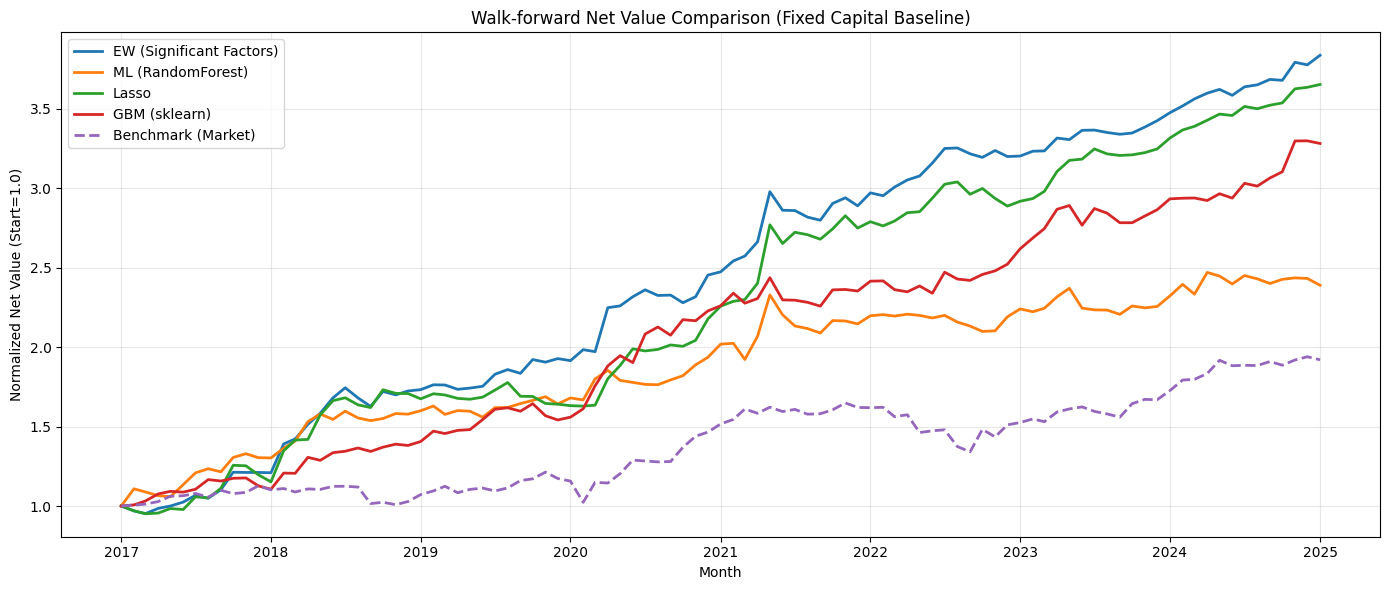

          策略           起始值           最終值     區間總報酬
0         EW  9.963471e+05  3.821365e+06  2.835375
1         ML  1.068318e+06  2.551776e+06  1.388593
2      Lasso  9.841385e+05  3.593679e+06  2.651599
3        GBM  1.070984e+06  3.513345e+06  2.280485
4  Benchmark  1.052718e+06  2.021025e+06  0.919816


In [22]:

# ===== Plot comparison: EW / ML / Lasso / GBM / Benchmark (fixed-capital baseline) =====
# 畫圖幾乎不花時間（約幾秒）；真正慢的是上一格的 walk-forward 回測。
# 若只要表格不要圖：改 RUN_PLOT = False 即可跳過本格。
RUN_PLOT = True

def build_benchmark_fixed_capital(data, initial_capital=1_000_000):
    """
    Build benchmark with the same fixed-capital baseline:
    each month PnL = initial_capital * benchmark next-month return.
    """
    if '下期大盤報酬率' in data.columns:
        tw = (
            data[['年/月', '下期大盤報酬率']]
            .dropna(subset=['年/月', '下期大盤報酬率'])
            .drop_duplicates(subset=['年/月'])
            .copy()
        )
        tw['下期大盤報酬率'] = pd.to_numeric(tw['下期大盤報酬率'], errors='coerce')
    elif '大盤月報酬' in data.columns:
        tw = (
            data[['年/月', '大盤月報酬']]
            .dropna(subset=['年/月', '大盤月報酬'])
            .drop_duplicates(subset=['年/月'])
            .copy()
        )
        tw['大盤月報酬'] = pd.to_numeric(tw['大盤月報酬'], errors='coerce')
        tw = tw.sort_values('年/月')
        tw['下期大盤報酬率'] = tw['大盤月報酬'].shift(-1)
    else:
        raise KeyError('需要「大盤月報酬」或「下期大盤報酬率」欄位才能畫 Benchmark')
    tw = tw.dropna(subset=['下期大盤報酬率'])
    tw = tw.sort_values('年/月')

    tw['持有期'] = pd.to_datetime(tw['年/月'], format='%Y/%m')
    tw['當月總損益'] = tw['下期大盤報酬率'] * initial_capital
    tw['累積損益'] = tw['當月總損益'].cumsum()
    tw['總價值'] = initial_capital + tw['累積損益']
    tw['月報酬率_固定本金'] = tw['當月總損益'] / initial_capital

    return tw[['持有期', '當月總損益', '累積損益', '總價值', '月報酬率_固定本金']]


bench_perf = build_benchmark_fixed_capital(df, initial_capital=INITIAL_CAPITAL)

plot_df = pd.DataFrame({'持有期': pd.to_datetime(bench_perf['持有期'])})
plot_df = plot_df.merge(
    bench_perf[['持有期', '總價值']].rename(columns={'總價值': 'Benchmark_總價值'}),
    on='持有期',
    how='left'
)

if 'wf_perf_eq' in globals() and not wf_perf_eq.empty:
    plot_df = plot_df.merge(
        wf_perf_eq[['持有期', '總價值']].rename(columns={'總價值': 'EW_總價值'}),
        on='持有期',
        how='left'
    )

if 'wf_perf_ml' in globals() and not wf_perf_ml.empty:
    plot_df = plot_df.merge(
        wf_perf_ml[['持有期', '總價值']].rename(columns={'總價值': 'ML_總價值'}),
        on='持有期',
        how='left'
    )

if 'wf_perf_lasso' in globals() and not wf_perf_lasso.empty:
    plot_df = plot_df.merge(
        wf_perf_lasso[['持有期', '總價值']].rename(columns={'總價值': 'Lasso_總價值'}),
        on='持有期',
        how='left'
    )

if 'wf_perf_gbm' in globals() and not wf_perf_gbm.empty:
    plot_df = plot_df.merge(
        wf_perf_gbm[['持有期', '總價值']].rename(columns={'總價值': 'GBM_總價值'}),
        on='持有期',
        how='left'
    )

plot_df = plot_df.sort_values('持有期').reset_index(drop=True)

# Keep only common period where all available series exist
value_cols = [c for c in ['EW_總價值', 'ML_總價值', 'Lasso_總價值', 'GBM_總價值', 'Benchmark_總價值'] if c in plot_df.columns]
plot_df_common = plot_df.dropna(subset=value_cols, how='any').copy()

# Normalize to 1.0 at start (same fixed-capital baseline view)
norm_df = plot_df_common.copy()
for col in value_cols:
    norm_df[col.replace('總價值', '淨值')] = norm_df[col] / norm_df[col].iloc[0]

if RUN_PLOT:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 6))

    if 'EW_淨值' in norm_df.columns:
        plt.plot(norm_df['持有期'], norm_df['EW_淨值'], label='EW (Significant Factors)', linewidth=2)
    if 'ML_淨值' in norm_df.columns:
        plt.plot(norm_df['持有期'], norm_df['ML_淨值'], label='ML (RandomForest)', linewidth=2)
    if 'Lasso_淨值' in norm_df.columns:
        plt.plot(norm_df['持有期'], norm_df['Lasso_淨值'], label='Lasso', linewidth=2)
    if 'GBM_淨值' in norm_df.columns:
        plt.plot(norm_df['持有期'], norm_df['GBM_淨值'], label='GBM (sklearn)', linewidth=2)
    if 'Benchmark_淨值' in norm_df.columns:
        plt.plot(norm_df['持有期'], norm_df['Benchmark_淨值'], label='Benchmark (Market)', linewidth=2, linestyle='--')

    plt.title('Walk-forward Net Value Comparison (Fixed Capital Baseline)')
    plt.xlabel('Month')
    plt.ylabel('Normalized Net Value (Start=1.0)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('RUN_PLOT=False: skipped matplotlib chart.')

# Quick performance summary
summary_rows = []
for name, col in [
    ('EW', 'EW_總價值'),
    ('ML', 'ML_總價值'),
    ('Lasso', 'Lasso_總價值'),
    ('GBM', 'GBM_總價值'),
    ('Benchmark', 'Benchmark_總價值'),
]:
    if col in plot_df_common.columns and not plot_df_common[col].empty:
        start_v = plot_df_common[col].iloc[0]
        end_v = plot_df_common[col].iloc[-1]
        total_ret = end_v / start_v - 1
        summary_rows.append({'策略': name, '起始值': start_v, '最終值': end_v, '區間總報酬': total_ret})

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

# Export comparison table
plot_df_common.to_csv(r"C:\python\tmba\wf_value_comparison.csv", index=False)
norm_df.to_csv(r"C:\python\tmba\wf_nav_comparison.csv", index=False)

In [23]:
# ===== Robustness summary table (on screen only; no CSV) =====
# Run the walk-forward cell first so wf_perf_eq / wf_perf_ml / wf_perf_lasso / wf_perf_gbm exist.

import numpy as np
from IPython.display import display

def _perf_slice(perf_df, start=None, end=None):
    if perf_df is None or perf_df.empty:
        return perf_df
    out = perf_df.copy()
    out['持有期'] = pd.to_datetime(out['持有期'])
    if start is not None:
        out = out[out['持有期'] >= pd.Timestamp(start)]
    if end is not None:
        out = out[out['持有期'] <= pd.Timestamp(end)]
    return out.sort_values('持有期').reset_index(drop=True)


def _metrics_from_perf(perf_df):
    if perf_df is None or perf_df.empty:
        return None
    r = pd.to_numeric(perf_df['月報酬率_固定本金'], errors='coerce').dropna()
    n = int(r.shape[0])
    if n < 6:
        return None
    tv = pd.to_numeric(perf_df['總價值'], errors='coerce')
    if tv.isna().all():
        return None
    total_ret = float(tv.iloc[-1] / tv.iloc[0] - 1)
    ann_ret = float((1 + total_ret) ** (12 / n) - 1)
    ann_vol = float(r.std() * np.sqrt(12))
    sharpe = float(ann_ret / ann_vol) if ann_vol > 0 else np.nan
    peak = tv.cummax()
    dd = (tv - peak) / peak.replace(0, np.nan)
    mdd = float(dd.min())
    win_rate = float((r > 0).mean())
    return {
        '月數': n,
        '區間總報酬': total_ret,
        '年化報酬': ann_ret,
        '年化波動': ann_vol,
        'Sharpe': sharpe,
        '最大回撤': mdd,
        '月勝率': win_rate,
        '_r': r.values,
    }


def _block_bootstrap_sharpe_ci(r, B=400, L=3, seed=42):
    r = np.asarray(r, dtype=float)
    n = r.size
    if n < max(12, L * 3):
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    sharps = []
    for _ in range(B):
        idx = []
        while len(idx) < n:
            s0 = int(rng.integers(0, n - L + 1))
            idx.extend(range(s0, min(s0 + L, n)))
        idx = idx[:n]
        rb = r[idx]
        m, s = rb.mean(), rb.std(ddof=1)
        if s == 0 or not np.isfinite(s):
            continue
        sharps.append((m / s) * np.sqrt(12))
    if len(sharps) < 50:
        return (np.nan, np.nan)
    q = np.quantile(sharps, [0.025, 0.975])
    return float(q[0]), float(q[1])


_perfs = [globals().get('wf_perf_eq'), globals().get('wf_perf_ml'),
          globals().get('wf_perf_lasso'), globals().get('wf_perf_gbm')]
if all(p is None or (hasattr(p, 'empty') and p.empty) for p in _perfs):
    print('請先執行 walk-forward 那一格，產生 wf_perf_* 後再跑本格。')

rows = []
scenarios = [
    ('全樣本', None, None),
    ('2015-01 起 ~ 2019-12', '2015-01-01', '2019-12-31'),
    ('2020-01 起 ~ 樣本末', '2020-01-01', None),
]

for label, s, e in scenarios:
    for name, perf in [
        ('EW', globals().get('wf_perf_eq')),
        ('ML', globals().get('wf_perf_ml')),
        ('Lasso', globals().get('wf_perf_lasso')),
        ('GBM', globals().get('wf_perf_gbm')),
    ]:
        sl = _perf_slice(perf, start=s, end=e)
        m = _metrics_from_perf(sl)
        if m is None:
            rows.append({
                '檢驗': label, '策略': name,
                '月數': 0, '區間總報酬': np.nan, '年化報酬': np.nan,
                '年化波動': np.nan, 'Sharpe': np.nan, '最大回撤': np.nan,
                '月勝率': np.nan, 'Sharpe_Boot_2.5%': np.nan, 'Sharpe_Boot_97.5%': np.nan,
            })
            continue
        rvec = m.pop('_r')
        lo, hi = _block_bootstrap_sharpe_ci(rvec)
        rows.append({
            '檢驗': label,
            '策略': name,
            '月數': m['月數'],
            '區間總報酬': m['區間總報酬'],
            '年化報酬': m['年化報酬'],
            '年化波動': m['年化波動'],
            'Sharpe': m['Sharpe'],
            '最大回撤': m['最大回撤'],
            '月勝率': m['月勝率'],
            'Sharpe_Boot_2.5%': lo,
            'Sharpe_Boot_97.5%': hi,
        })

robustness_summary = pd.DataFrame(rows)
num_cols = [c for c in robustness_summary.columns if c not in ('檢驗', '策略')]
robustness_summary[num_cols] = robustness_summary[num_cols].apply(pd.to_numeric, errors='coerce')

# 顯示用格式（百分比欄位）
show = robustness_summary.copy()
for c in ['區間總報酬', '年化報酬', '年化波動', '最大回撤', '月勝率', 'Sharpe', 'Sharpe_Boot_2.5%', 'Sharpe_Boot_97.5%']:
    if c in show.columns:
        if c in ('月勝率', '區間總報酬', '年化報酬', '年化波動', '最大回撤'):
            show[c] = show[c].map(lambda x: f'{100*x:.2f}%' if pd.notna(x) else '')
        else:
            show[c] = show[c].map(lambda x: f'{x:.3f}' if pd.notna(x) else '')

print('Robustness summary (point estimates + block-bootstrap Sharpe 95% CI, L=3, B=400)')
display(show)


Robustness summary (point estimates + block-bootstrap Sharpe 95% CI, L=3, B=400)


,檢驗,策略,月數,區間總報酬,年化報酬,年化波動,Sharpe,最大回撤,月勝率,Sharpe_Boot_2.5%,Sharpe_Boot_97.5%
0,全樣本,EW,98,284.65%,17.93%,21.18%,0.847,-6.74%,67.35%,1.118,2.250
1,全樣本,ML,98,146.04%,11.65%,21.26%,0.548,-10.31%,54.08%,0.369,1.458
2,全樣本,Lasso,98,259.15%,16.95%,22.58%,0.751,-8.35%,62.24%,0.932,1.951
3,全樣本,GBM,98,228.97%,15.70%,21.36%,0.735,-7.35%,65.31%,0.933,2.123
4,2015-01 起 ~ 2019-12,EW,36,92.72%,24.44%,17.65%,1.385,-6.74%,63.89%,0.961,2.964
5,2015-01 起 ~ 2019-12,ML,36,64.20%,17.98%,16.30%,1.103,-4.46%,61.11%,0.663,2.591
6,2015-01 起 ~ 2019-12,Lasso,36,64.05%,17.94%,21.14%,0.849,-8.31%,44.44%,0.063,1.959
7,2015-01 起 ~ 2019-12,GBM,36,54.13%,15.51%,14.38%,1.079,-6.23%,66.67%,0.605,2.750
8,2020-01 起 ~ 樣本末,EW,62,100.93%,14.46%,23.09%,0.626,-6.02%,69.35%,0.993,2.535
9,2020-01 起 ~ 樣本末,ML,62,46.46%,7.66%,23.75%,0.323,-10.31%,50.00%,0.024,1.295


In [ ]:
# ===== 統整 walkforward_results.xlsx → walkforward_summary.xlsx =====
# 一目瞭然：績效總覽、月報酬對照、因子明細與頻率、標的多空統計、每月持股
# 依賴：pip install openpyxl pandas
import numpy as np
import pandas as pd
from pathlib import Path
try:
    from IPython.display import display
except ImportError:
    display = print

SRC = Path(r"C:\python\tmba\walkforward_results.xlsx")
OUT = Path(r"C:\python\tmba\walkforward_summary.xlsx")

if not SRC.is_file():
    raise FileNotFoundError(f"找不到 {SRC}，請先執行回測並輸出 walkforward_results.xlsx")

xl = pd.ExcelFile(SRC, engine="openpyxl")
sheets = {name: pd.read_excel(SRC, sheet_name=name, engine="openpyxl") for name in xl.sheet_names}


def _pick_col(df, *names):
    for n in names:
        if n in df.columns:
            return n
    return None


def perf_summary(perf_df, strategy_name):
    if perf_df is None or perf_df.empty:
        return {"策略": strategy_name}
    df = perf_df.copy()
    c_date = _pick_col(df, "持有期") or df.columns[0]
    c_r = _pick_col(df, "月報酬率_固定本金")
    c_tv = _pick_col(df, "總價值")
    c_to = _pick_col(df, "換手率")
    df[c_date] = pd.to_datetime(df[c_date], errors="coerce")
    df = df.dropna(subset=[c_date])
    r = pd.to_numeric(df[c_r], errors="coerce").dropna() if c_r else pd.Series(dtype=float)
    tv = pd.to_numeric(df[c_tv], errors="coerce") if c_tv else pd.Series(dtype=float)
    n = int(r.shape[0])
    if n < 2 or tv.shape[0] < 2:
        return {"策略": strategy_name, "月數": n}
    total_ret = float(tv.iloc[-1] / tv.iloc[0] - 1)
    ann_ret = float((1 + total_ret) ** (12 / n) - 1)
    ann_vol = float(r.std() * np.sqrt(12)) if n > 1 else np.nan
    sharpe = float(ann_ret / ann_vol) if ann_vol and ann_vol > 0 else np.nan
    peak = tv.cummax()
    dd = (tv - peak) / peak.replace(0, np.nan)
    mdd = float(dd.min())
    win_rate = float((r > 0).mean())
    avg_turn = float(pd.to_numeric(df[c_to], errors="coerce").mean()) if c_to else np.nan
    return {
        "策略": strategy_name,
        "樣本起": df[c_date].iloc[0],
        "樣本迄": df[c_date].iloc[-1],
        "月數": n,
        "期初總價值": float(tv.iloc[0]),
        "期末總價值": float(tv.iloc[-1]),
        "區間總報酬": total_ret,
        "年化報酬": ann_ret,
        "年化波動": ann_vol,
        "Sharpe": sharpe,
        "最大回撤": mdd,
        "月勝率": win_rate,
        "平均換手率": avg_turn,
    }


def normalize_factors_df(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=["持有期", "selected_factors"])
    out = df.copy()
    if "持有期" not in out.columns and len(out.columns) >= 1:
        out = out.rename(columns={out.columns[0]: "持有期"})
    if "selected_factors" not in out.columns and len(out.columns) >= 2:
        out = out.rename(columns={out.columns[1]: "selected_factors"})
    return out


def factors_long(factors_df, strategy):
    fac = normalize_factors_df(factors_df)
    if fac.empty:
        return pd.DataFrame(columns=["策略", "持有期", "因子"])
    rows = []
    for _, row in fac.iterrows():
        t, s = row.get("持有期"), row.get("selected_factors", "")
        if pd.isna(s) or str(s).strip() == "":
            continue
        for part in str(s).split(","):
            part = part.strip()
            if part:
                rows.append({"策略": strategy, "持有期": t, "因子": part})
    return pd.DataFrame(rows)


def positions_monthly_holdings(pos_df, strategy):
    if pos_df is None or pos_df.empty:
        return pd.DataFrame(columns=["策略", "年/月", "多頭_代號", "空頭_代號", "多頭檔數", "空頭檔數"])
    p = pos_df.copy()
    c_sym = _pick_col(p, "代號") or p.columns[0]
    c_m = _pick_col(p, "年/月") or p.columns[1]
    c_side = _pick_col(p, "持仓") or p.columns[2]
    p[c_sym] = p[c_sym].astype(str)
    p[c_m] = p[c_m].astype(str)

    def join_codes(g):
        return ", ".join(sorted(g.astype(str).unique()))

    longs = (
        p[p[c_side] == "LONG"]
        .groupby(c_m, sort=False)[c_sym]
        .apply(join_codes)
        .rename("多頭_代號")
    )
    shorts = (
        p[p[c_side] == "SHORT"]
        .groupby(c_m, sort=False)[c_sym]
        .apply(join_codes)
        .rename("空頭_代號")
    )
    out = pd.concat([longs, shorts], axis=1).reset_index().rename(columns={c_m: "年/月"})
    out["策略"] = strategy
    out["多頭檔數"] = out["多頭_代號"].fillna("").apply(lambda x: len([z for z in x.split(",") if z.strip()]) if x else 0)
    out["空頭檔數"] = out["空頭_代號"].fillna("").apply(lambda x: len([z for z in x.split(",") if z.strip()]) if x else 0)
    return out[["策略", "年/月", "多頭_代號", "空頭_代號", "多頭檔數", "空頭檔數"]]


def symbol_long_short_counts(pos_df, strategy):
    if pos_df is None or pos_df.empty:
        return pd.DataFrame()
    p = pos_df.copy()
    c_sym = _pick_col(p, "代號") or p.columns[0]
    c_m = _pick_col(p, "年/月") or p.columns[1]
    c_side = _pick_col(p, "持仓") or p.columns[2]
    p[c_sym] = p[c_sym].astype(str)
    long_n = p[p[c_side] == "LONG"].groupby(c_sym).size().rename("LONG_月數")
    short_n = p[p[c_side] == "SHORT"].groupby(c_sym).size().rename("SHORT_月數")
    out = pd.concat([long_n, short_n], axis=1).fillna(0).astype(int).reset_index().rename(columns={c_sym: "代號"})
    out["策略"] = strategy
    out["多空_月數加總"] = out["LONG_月數"] + out["SHORT_月數"]
    fl = p.groupby(c_sym)[c_m].agg(["min", "max"]).reset_index()
    fl = fl.rename(columns={c_sym: "代號", "min": "首次年月", "max": "末次年月"})
    out = out.merge(fl, on="代號", how="left")
    return out.sort_values(["策略", "多空_月數加總"], ascending=[True, False])


# --- 1) 績效總覽 ---
perf_map = [
    ("EW", "EW_perf"),
    ("ML_RF", "ML_perf"),
    ("Lasso", "Lasso_perf"),
    ("GBM", "GBM_perf"),
]
summary_rows = []
for label, sh in perf_map:
    summary_rows.append(perf_summary(sheets.get(sh), label))
df_summary = pd.DataFrame(summary_rows)
for c in ["區間總報酬", "年化報酬", "年化波動", "Sharpe", "最大回撤", "月勝率", "平均換手率"]:
    if c in df_summary.columns:
        df_summary[c] = pd.to_numeric(df_summary[c], errors="coerce")

# --- 2) 月報酬對照（寬表）---
df_monthly = sheets.get("monthly_rets", pd.DataFrame()).copy()
if not df_monthly.empty:
    tcol = _pick_col(df_monthly, "持有期") or df_monthly.columns[0]
    df_monthly[tcol] = pd.to_datetime(df_monthly[tcol], errors="coerce")
    df_monthly = df_monthly.sort_values(tcol)

# --- 3) 因子長表 + 頻率 ---
factor_specs = [
    ("EW", "EW_factors"),
    ("ML_RF", "ML_factors"),
    ("Lasso", "Lasso_factors"),
    ("GBM", "GBM_factors"),
]
factor_parts = [factors_long(sheets.get(sh), lab) for lab, sh in factor_specs if sh in sheets]
df_factors_long = pd.concat(factor_parts, ignore_index=True) if factor_parts else pd.DataFrame()

df_factor_rank = pd.DataFrame()
if not df_factors_long.empty:
    df_factors_long["持有期"] = df_factors_long["持有期"].astype(str)
    months_n = df_factors_long.groupby("策略")["持有期"].nunique().rename("策略_總月數")
    fc = df_factors_long.groupby(["策略", "因子"]).size().reset_index(name="入選月數")
    fc = fc.merge(months_n.reset_index(), on="策略")
    fc["入選月數占比"] = fc["入選月數"] / fc["策略_總月數"].replace(0, np.nan)
    df_factor_rank = fc.sort_values(["策略", "入選月數"], ascending=[True, False])

# --- 4) 每月持股 + 標的統計 ---
pos_specs = [
    ("EW", "EW_positions"),
    ("ML_RF", "ML_positions"),
    ("Lasso", "Lasso_positions"),
    ("GBM", "GBM_positions"),
]
hold_parts = [positions_monthly_holdings(sheets.get(sh), lab) for lab, sh in pos_specs if sh in sheets]
df_holdings = pd.concat(hold_parts, ignore_index=True) if hold_parts else pd.DataFrame()

sym_parts = [symbol_long_short_counts(sheets.get(sh), lab) for lab, sh in pos_specs if sh in sheets]
df_symbols = pd.concat(sym_parts, ignore_index=True) if sym_parts else pd.DataFrame()

# --- 5) 說明頁 ---
readme = pd.DataFrame(
    {
        "工作表": [
            "00_說明",
            "01_績效總覽",
            "02_月報酬對照",
            "03_因子_每月一列",
            "04_因子_入選頻率排行",
            "05_每月持股_多空代號",
            "06_標的_多空月數統計",
            "99_來源工作表清單",
        ],
        "內容": [
            "本檔由 walkforward_results.xlsx 自動彙總；數字欄位可直接篩選排序。",
            "各策略樣本區間、月數、報酬與風險指標（與 notebook 定義一致）。",
            "各策略月度報酬並列（來源：monthly_rets）。",
            "每期選入的因子拆成一行一因子，便於篩選與樞紐。",
            "因子在該策略下「出現的月份數」及占該策略總月數比例。",
            "每月多頭／空頭持股代號（逗號分隔）。",
            "各股票代號出現在 LONG / SHORT 的月數與首次／末次年月。",
            "讀入的原始 Excel 工作表名稱列表。",
        ],
    }
)
df_sources = pd.DataFrame({"來源工作表": xl.sheet_names})

# --- 輸出 Excel ---
with pd.ExcelWriter(OUT, engine="openpyxl") as writer:
    readme.to_excel(writer, sheet_name="00_說明", index=False)
    df_summary.to_excel(writer, sheet_name="01_績效總覽", index=False)
    if not df_monthly.empty:
        df_monthly.to_excel(writer, sheet_name="02_月報酬對照", index=False)
    else:
        pd.DataFrame({"提示": ["無 monthly_rets 工作表"]}).to_excel(writer, sheet_name="02_月報酬對照", index=False)
    if not df_factors_long.empty:
        df_factors_long.to_excel(writer, sheet_name="03_因子_每月一列", index=False)
    else:
        pd.DataFrame({"提示": ["無因子工作表"]}).to_excel(writer, sheet_name="03_因子_每月一列", index=False)
    if not df_factor_rank.empty:
        df_factor_rank.to_excel(writer, sheet_name="04_因子_入選頻率排行", index=False)
    else:
        pd.DataFrame({"提示": ["無因子資料"]}).to_excel(writer, sheet_name="04_因子_入選頻率排行", index=False)
    if not df_holdings.empty:
        df_holdings.to_excel(writer, sheet_name="05_每月持股_多空代號", index=False)
    else:
        pd.DataFrame({"提示": ["無持股工作表"]}).to_excel(writer, sheet_name="05_每月持股_多空代號", index=False)
    if not df_symbols.empty:
        df_symbols.to_excel(writer, sheet_name="06_標的_多空月數統計", index=False)
    else:
        pd.DataFrame({"提示": ["無持股資料"]}).to_excel(writer, sheet_name="06_標的_多空月數統計", index=False)
    df_sources.to_excel(writer, sheet_name="99_來源工作表清單", index=False)

print(f"已輸出：{OUT}")
display(df_summary)